In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Tensorflow-Models

Mounted at /content/gdrive
/content/gdrive/.shortcut-targets-by-id/1oP3ewZgiatY88SU5esvVcTCqbdfjYu1d/Tensorflow-Models


In [2]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".txt"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("LaPa/train/images")
count_images("LaPa/train/landmarks")

Total images: 18168
Total images: 18168


In [ ]:
import os

image_dir = "LaPa/train/images"
landmark_dir = "LaPa/train/landmarks"

# valid image extensions
image_exts = {".jpg", ".jpeg", ".png", ".bmp"}

# get basenames (without extension)
image_basenames = {os.path.splitext(f)[0] for f in os.listdir(image_dir)
                   if os.path.splitext(f.lower())[1] in image_exts}

landmark_files = os.listdir(landmark_dir)

extra_landmarks = []
for f in landmark_files:
    name, ext = os.path.splitext(f)
    if ext.lower() == ".txt" and name not in image_basenames:
        extra_landmarks.append(f)

print(f"Found {len(extra_landmarks)} extra landmark files.")

Found 7 extra landmark files.


In [ ]:
for f in extra_landmarks:
    path = os.path.join(landmark_dir, f)
    os.remove(path)
    print(f"Removed: {path}")

print("Cleanup finished ✅")

Removed: LaPa/train/landmarks/HELEN_2541637575_1_0 (1).txt
Removed: LaPa/train/landmarks/HELEN_2541112439_2_5 (1).txt
Removed: LaPa/train/landmarks/HELEN_2541637575_1_1 (1).txt
Removed: LaPa/train/landmarks/HELEN_2541112439_2_2 (1).txt
Removed: LaPa/train/landmarks/HELEN_2541112439_2_1 (1).txt
Removed: LaPa/train/landmarks/HELEN_2541125327_1_0 (1).txt
Removed: LaPa/train/landmarks/HELEN_1238081332_1_0 (1).txt
Cleanup finished ✅


In [3]:
import os
import numpy as np
import cv2
from glob import glob
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers as L
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, CSVLogger

In [4]:
def load_dataset(path):
    train_x = sorted(glob(os.path.join(path, "train", "images", "*.jpg")))
    train_y = sorted(glob(os.path.join(path, "train", "landmarks", "*.txt")))

    valid_x = sorted(glob(os.path.join(path, "val", "images", "*.jpg")))
    valid_y = sorted(glob(os.path.join(path, "val", "landmarks", "*.txt")))

    test_x = sorted(glob(os.path.join(path, "test", "images", "*.jpg")))
    test_y = sorted(glob(os.path.join(path, "test", "landmarks", "*.txt")))

    return (train_x, train_y), (valid_x, valid_y), (test_x, test_y)

def read_image_lankmarks(image_path, landmark_path):
    """ Image """
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    h, w, _ = image.shape
    image = cv2.resize(image, (image_w, image_h))
    image = image/255.0
    image = image.astype(np.float32)

    """ Lankmarks """
    data = open(landmark_path, "r").read()
    lankmarks = []

    for line in data.strip().split("\n")[1:]:
        x, y = line.split(" ")
        x = float(x)/w
        y = float(y)/h

        lankmarks.append(x)
        lankmarks.append(y)

    lankmarks = np.array(lankmarks, dtype=np.float32)

    return image, lankmarks

def preprocess(x, y):
    def f(x, y):
        x = x.decode()
        y = y.decode()

        image, landmarks = read_image_lankmarks(x, y)
        return image, landmarks

    image, landmarks = tf.numpy_function(f, [x, y], [tf.float32, tf.float32])
    image.set_shape([image_h, image_w, 3])
    landmarks.set_shape([num_landmarks * 2])

    return image, landmarks

def tf_dataset(x, y, batch=8):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.shuffle(buffer_size=5000).map(preprocess)
    ds = ds.batch(batch).prefetch(2)
    return ds

In [5]:
""" Hyperparameters """
image_h = 512
image_w = 512
num_landmarks = 106
input_shape = (image_h, image_w, 3)
batch_size = 32
lr = 1e-3

""" Paths """
dataset_path = "LaPa"

""" Loading the dataset """
(train_x, train_y), (valid_x, valid_y), (test_x, test_y) = load_dataset(dataset_path)
print(f"Train: {len(train_x)}/{len(train_y)} - Valid: {len(valid_x)}/{len(valid_y)} - Test: {len(test_x)}/{len(test_x)}")
print("")

# """ Dataset Pipeline """
# train_ds = tf_dataset(train_x, train_y, batch=batch_size)
# valid_ds = tf_dataset(valid_x, valid_y, batch=batch_size)

Train: 18168/18168 - Valid: 2000/2000 - Test: 2000/2000



In [6]:
# Restrict to target sizes
train_limit = 4000
val_limit = 500
test_limit = 500

train_x, train_y = train_x[:train_limit], train_y[:train_limit]
valid_x, valid_y = valid_x[:val_limit], valid_y[:val_limit]
test_x, test_y   = test_x[:test_limit], test_y[:test_limit]

print(f"Train: {len(train_x)} - Valid: {len(valid_x)} - Test: {len(test_x)}")

""" Dataset Pipeline """
train_ds = tf_dataset(train_x, train_y, batch=batch_size)
valid_ds = tf_dataset(valid_x, valid_y, batch=batch_size)
test_ds  = tf_dataset(test_x, test_y, batch=batch_size)

Train: 4000 - Valid: 500 - Test: 500


In [7]:
def build_model(input_shape, num_landmarks):
    inputs = L.Input(input_shape)

    backbone = MobileNetV2(include_top=False, weights="imagenet", input_tensor=inputs, alpha=0.5)
    backbone.trainable = True

    x = backbone.output
    x = L.GlobalAveragePooling2D()(x)
    x = L.Dropout(0.2)(x)
    outputs = L.Dense(num_landmarks*2, activation="sigmoid")(x)

    model = tf.keras.models.Model(inputs, outputs)
    return model

""" Model """
model = build_model(input_shape, num_landmarks)
model.summary()

/tmp/ipython-input-1435648425.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(include_top=False, weights="imagenet", input_tensor=inputs, alpha=0.5)


3201480/3201480 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 256, 256,  │        432 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 256, 256,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 256, 256,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 256, 256,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 256, 256,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 256, 256,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 256, 256,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 256, 256,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 256, 256,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 256, 256,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 256, 256,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 257, 257,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 128, 128,  │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 128, 128,  │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 128, 128,  │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 128, 128,  │        768 │ block_1_depthwis

 Total params: 977,796 (3.73 MB)

 Trainable params: 959,252 (3.66 MB)

 Non-trainable params: 18,544 (72.44 KB)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(lr),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
    ]
)
checkpoint_filepath = "MobileNetV2_keypoints.weights.h5"

""" Training """
callbacks = [
    ModelCheckpoint(checkpoint_filepath, monitor="val_loss", save_best_only=True, save_weights_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, min_lr=1e-7, verbose=1),
]

In [9]:
num_epochs = 50

history = model.fit(train_ds,
    validation_data=valid_ds,
    epochs=num_epochs,
    callbacks=callbacks
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 75s/step - loss: 0.6739 - mae: 0.0550  
Epoch 1: val_loss improved from inf to 3.35196, saving model to MobileNetV2_keypoints.weights.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 10664s 85s/step - loss: 0.6738 - mae: 0.0549 - val_loss: 3.3520 - val_mae: 0.3684 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - loss: 0.6635 - mae: 0.0282
Epoch 2: val_loss improved from 3.35196 to 1.38492, saving model to MobileNetV2_keypoints.weights.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 58s 460ms/step - loss: 0.6635 - mae: 0.0282 - val_loss: 1.3849 - val_mae: 0.2965 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - loss: 0.6624 - mae: 0.0217
Epoch 3: val_loss improved from 1.38492 to 1.15530, saving model to MobileNetV2_keypoints.weights.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 57s 452ms/step - loss: 0.6624 - mae: 0.0217 - val_loss: 1.1553 - val_mae: 0.2688 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/

In [10]:
# Generate predictions for all images in the validation set
checkpoint_filepath = "MobileNetV2_keypoints.weights.h5"
model.load_weights(checkpoint_filepath)

In [11]:
img, gt = read_image_lankmarks(train_x[0], train_y[0])
pred = model.predict(img[np.newaxis], verbose=0)[0]
print("GT[0:10]:", gt[:10])
print("Pred[0:10]:", pred[:10])

GT[0:10]: [0.2159091  0.4817073  0.21789017 0.5009946  0.23057985 0.5219639
 0.23595874 0.54120547 0.24564074 0.5642953 ]
Pred[0:10]: [0.2110314  0.48252115 0.21945266 0.5031447  0.22523682 0.52552295
 0.22943324 0.54443884 0.23967639 0.56494117]


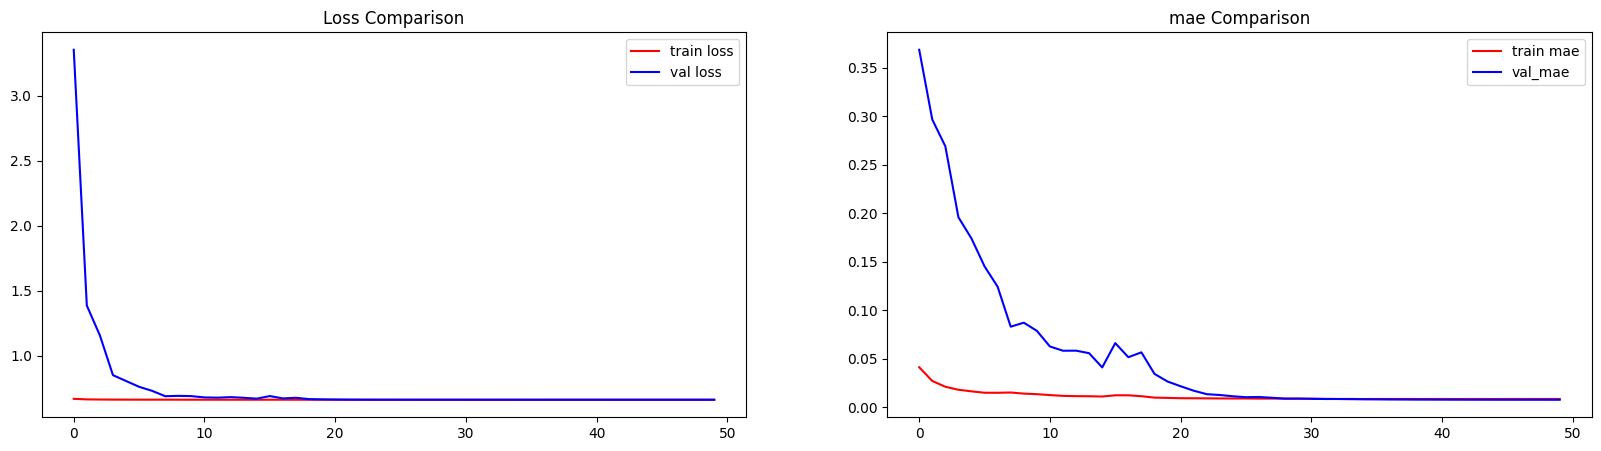

In [14]:
import matplotlib.pyplot as plt
fig, axis = plt.subplots(1, 2, figsize=(20, 5))
axis[0].plot(history.history["loss"], color='r', label = 'train loss')
axis[0].plot(history.history["val_loss"], color='b', label = 'val loss')
axis[0].set_title('Loss Comparison')
axis[0].legend()
axis[1].plot(history.history["mae"], color='r', label = 'train mae')
axis[1].plot(history.history["val_mae"], color='b', label = 'val_mae')
axis[1].set_title('mae Comparison')
axis[1].legend()

In [12]:
import random
import matplotlib.pyplot as plt

def plot_landmarks(image, landmarks, color=(255, 0, 0)):
    h, w, _ = image.shape
    radius = int(h * 0.005)
    for i in range(0, len(landmarks), 2):
        x = int(landmarks[i] * w)
        y = int(landmarks[i+1] * h)
        image = cv2.circle(image, (x, y), radius, color, -1)
    return image

In [13]:
def inference_fn(samples):
    plt.figure(figsize=(15, 8))

    for idx, (img_path, lm_path) in enumerate(samples, 1):
        # Original image
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        h, w, _ = image.shape

        # Preprocess for model
        inp = cv2.resize(image, (image_w, image_h))
        inp = inp / 255.0
        inp = np.expand_dims(inp.astype(np.float32), axis=0)

        # Ground truth landmarks
        data = open(lm_path, "r").read()
        gt = []
        for line in data.strip().split("\n")[1:]:
            x, y = line.split(" ")
            x = float(x) / w
            y = float(y) / h
            gt.extend([x, y])
        gt = np.array(gt, dtype=np.float32)

        # Prediction
        pred = model.predict(inp, verbose=0)[0]

        # Draw
        gt_img = plot_landmarks(image.copy(), gt, color=(0, 255, 0))   # green = GT
        pred_img = plot_landmarks(image.copy(), pred, color=(0, 0, 255)) # red = Pred

        # Show side by side
        cat = np.concatenate([gt_img, pred_img], axis=1)
        cat = cv2.cvtColor(cat, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 2, idx)
        plt.imshow(cat)
        plt.axis("off")
        plt.title(f"Sample {idx}: GT (left) vs Pred (right)")

    plt.tight_layout()
    plt.show()

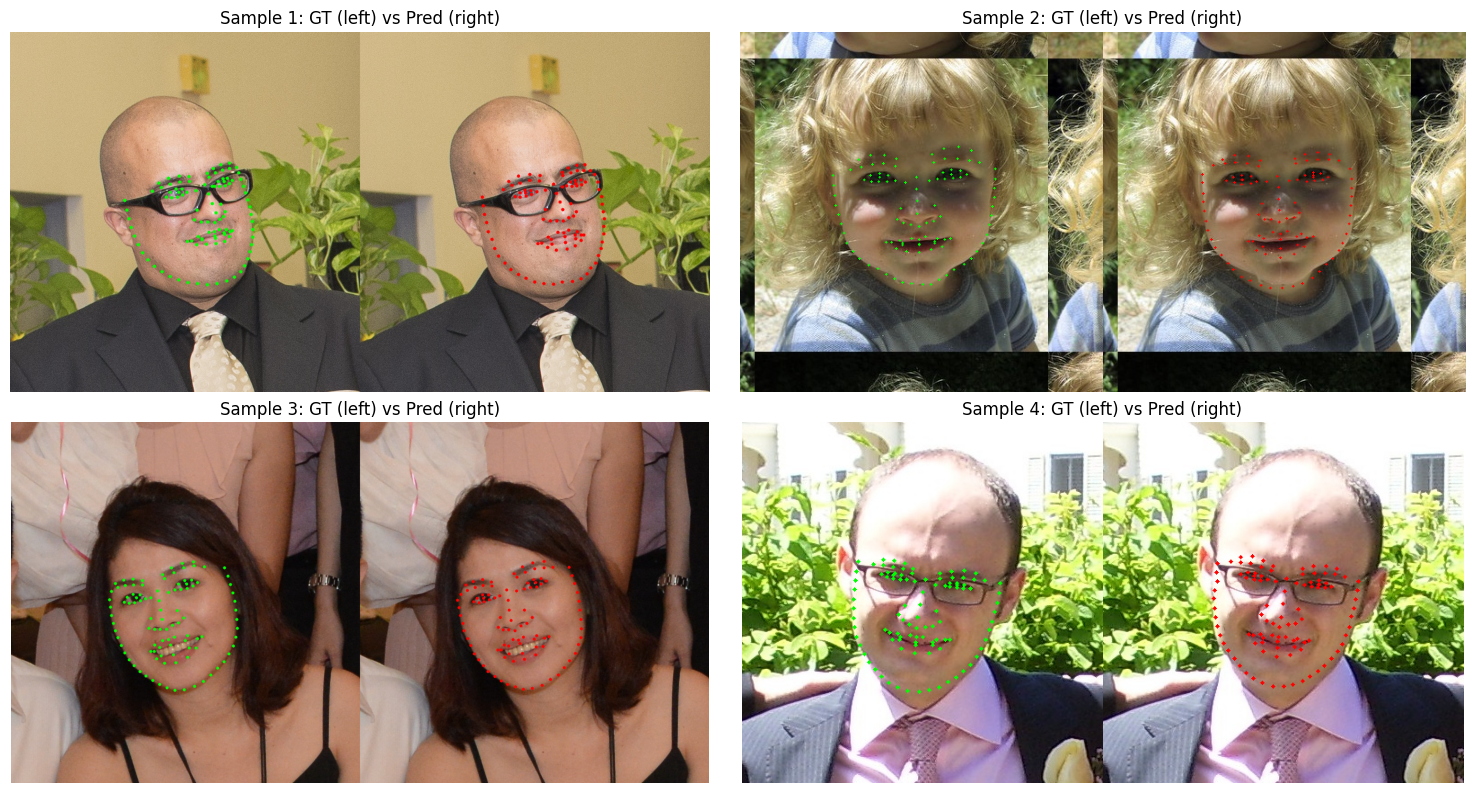

In [15]:
# Pick 4 random validation samples
samples = random.sample(list(zip(valid_x, valid_y)), 4)
inference_fn(samples)

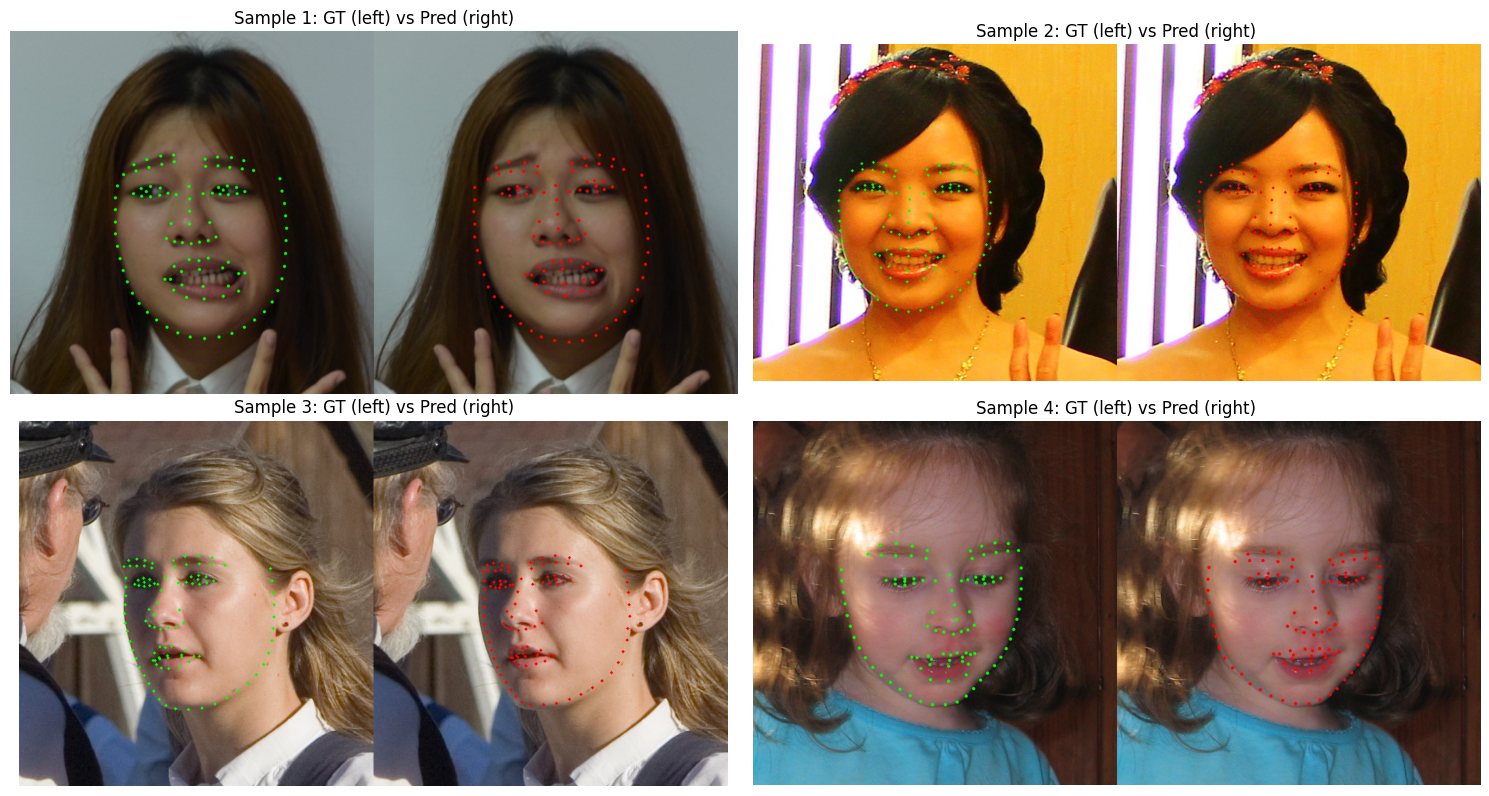

In [16]:
samples = random.sample(list(zip(test_x, test_y)), 4)
inference_fn(samples)

In [17]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

def plot_landmarks(image, landmarks, color=(255, 0, 0)):
    h, w, _ = image.shape
    radius = max(1, int(h * 0.005))
    for i in range(0, len(landmarks), 2):
        x = int(landmarks[i] * w)
        y = int(landmarks[i+1] * h)
        image = cv2.circle(image, (x, y), radius, color, -1)
    return image

def inference_folder(folder, n_samples=4):
    # Collect only image files
    files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".png"))]
    samples = random.sample(files, min(n_samples, len(files)))

    rows = (len(samples) + 3) // 4   # ceiling division
    plt.figure(figsize=(15, 4 * rows))
    for idx, img_file in enumerate(samples, 1):
        img_path = os.path.join(folder, img_file)
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        h, w, _ = image.shape

        # Preprocess for model
        inp = cv2.resize(image, (image_w, image_h))
        inp = inp / 255.0
        inp = np.expand_dims(inp.astype(np.float32), axis=0)

        # Prediction
        pred = model.predict(inp, verbose=0)[0]

        # Draw prediction only
        pred_img = plot_landmarks(image.copy(), pred, color=(0, 0, 255))
        pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

        # Plot
        plt.subplot(rows, 4, idx)
        plt.imshow(pred_img)
        plt.axis("off")
        plt.title(f"Pred {idx}")

    plt.tight_layout()
    plt.show()

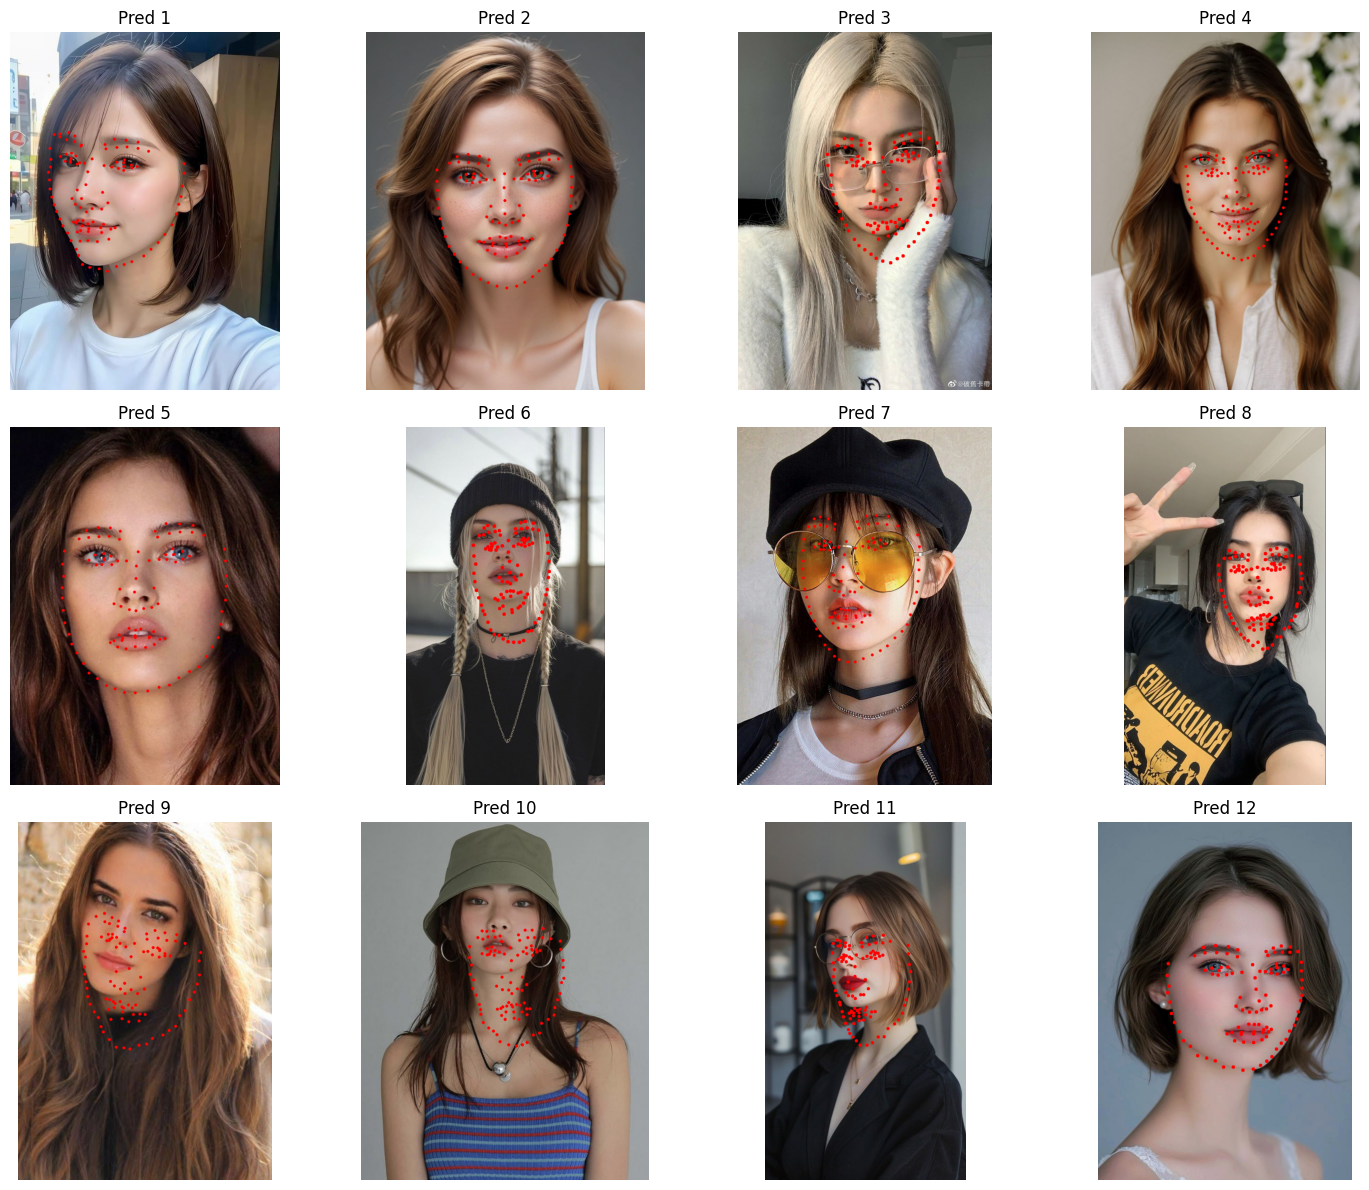

In [20]:
# Run inference on face-tests/
inference_folder("/content/gdrive/MyDrive/Hugging Face/datasets/face-tests/", n_samples=12)

In [21]:
# Serialize the model as a SavedModel.
# Use model.export for Keras models
model.export("MobileNetV2_keypoints")

import tensorflow as tf
# Convert to TFLite. This form of quantization is called
# post-training dynamic-range quantization in TFLite.
converter = tf.lite.TFLiteConverter.from_saved_model("MobileNetV2_keypoints")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,  # Enable TensorFlow Lite ops.
    tf.lite.OpsSet.SELECT_TF_OPS,  # Enable TensorFlow ops.
]
tflite_model = converter.convert()
open("MobileNetV2_keypoints.tflite", "wb").write(tflite_model)

Saved artifact at 'MobileNetV2_keypoints'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 212), dtype=tf.float32, name=None)
Captures:
  140420905493392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140420905493776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140420905496272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140420905495696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140420905494928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140420905493584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140420905496464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140420905497232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140420905496848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140420905495888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1404209

1136696

In [23]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="MobileNetV2_keypoints.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Get input size (h, w, c)
input_shape = input_details[0]['shape'][1:3]

def plot_landmarks(image, landmarks, color=(255, 0, 0)):
    h, w, _ = image.shape
    radius = max(1, int(h * 0.005))
    for i in range(0, len(landmarks), 2):
        x = int(landmarks[i] * w)
        y = int(landmarks[i+1] * h)
        image = cv2.circle(image, (x, y), radius, color, -1)
    return image

def preprocess_image(img_path, target_size):
    img = Image.open(img_path).convert("RGB").resize(target_size, Image.BILINEAR)
    arr = np.array(img, dtype=np.float32) / 255.0   # normalize
    return arr

def run_tflite_inference(img_path):
    img = preprocess_image(img_path, tuple(input_shape))
    inp = np.expand_dims(img, axis=0)  # [1,h,w,c]

    # Run inference
    interpreter.set_tensor(input_details[0]['index'], inp)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])[0]

    return output  # already normalized landmark coords [x1,y1,...]

def inference_folder_tflite(folder, n_samples=4):
    files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".png"))]
    samples = random.sample(files, min(n_samples, len(files)))

    rows = (len(samples) + 3) // 4
    plt.figure(figsize=(15, 4 * rows))

    for idx, img_file in enumerate(samples, 1):
        img_path = os.path.join(folder, img_file)
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)

        # Predict with TFLite model
        pred = run_tflite_inference(img_path)

        # Draw prediction
        pred_img = plot_landmarks(image.copy(), pred, color=(0, 0, 255))
        pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, 4, idx)
        plt.imshow(pred_img)
        plt.axis("off")
        plt.title(f"Pred {idx}")

    plt.tight_layout()
    plt.show()

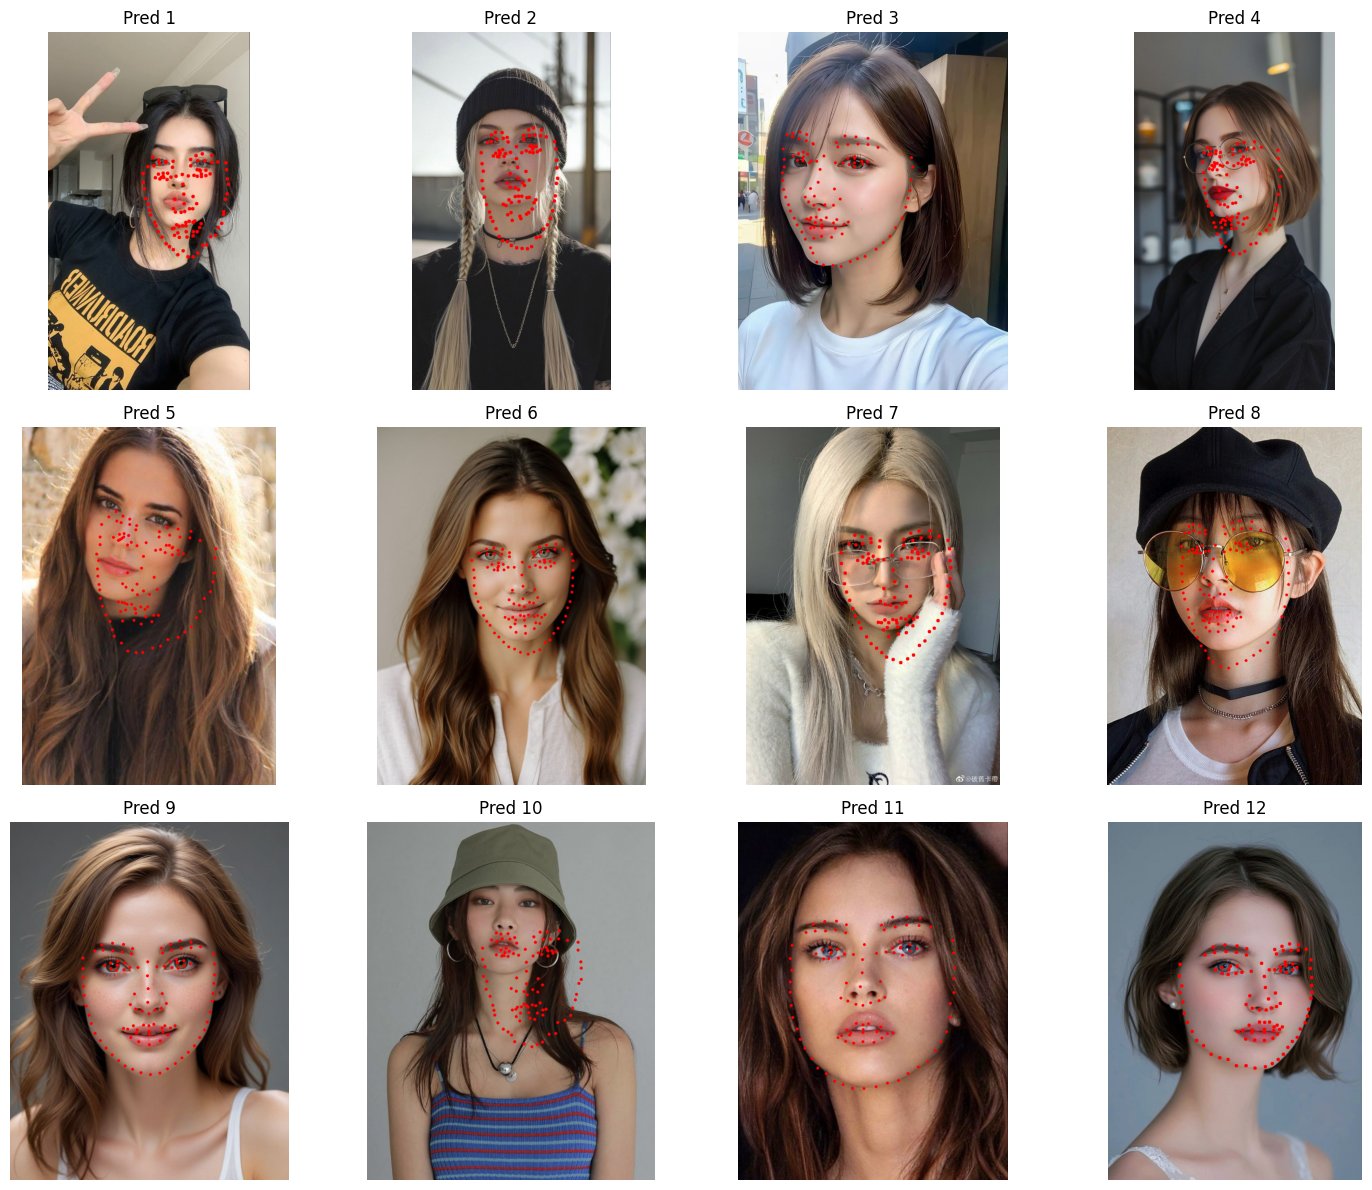

In [24]:
# Example usage
inference_folder_tflite("/content/gdrive/MyDrive/Hugging Face/datasets/face-tests/", n_samples=12)